In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torchvision
import torch

from cv_tools.utils import COCOEvalPlus
import plot_utils as pu
import os
from cv_tools import utils
import config as C
import scipy

%load_ext autoreload
%autoreload 1
%aimport config
%aimport plot_utils
%aimport cv_tools.utils

data_dir = C.DATA_DIR
results_dir = C.RESULTS_DIR
_ = C.setup_plotting(rc=C.RC_PAPER)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Hand-picked visual examples of image enhancement and detection results

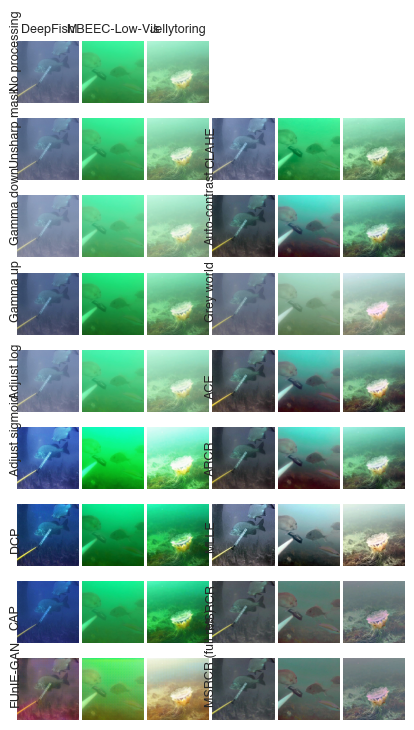

In [5]:
FILENAMES = {
    'DeepFish': ('9866_acanthopagrus_and_caranx_f000054.jpg', 0.7, 0.3),
    'GLOW_low_visibility_estuaries': ('SH4b-27-08-2018_SH4b BRUV 27 August 2018 (1)-17-of-27.MP4_5fps_000012.jpg', 0.7, 0.3),
    'Jellytoring': ('lamarckii3_13.jpg', 0.7, 0.3),
}

first_half = int(np.ceil(len(C.ALL_PPS) / 2))
PPS = [None] + C.ALL_PPS[:first_half] + [None] + C.ALL_PPS[first_half:] + ['resized_MSRCR_15_80_250_fk']
assert len(PPS) % 2 == 0
fig, axs = plt.subplots(int(len(PPS) / 2), 2 * len(FILENAMES),
                        figsize=(2 * len(FILENAMES) - 1, int(len(PPS) / 2)))
plt.subplots_adjust(wspace=0.05, hspace=0.01)

for row, pps in enumerate(PPS):
    for col, dataset in enumerate(FILENAMES):
        fn, offset_left, offset_right = FILENAMES[dataset]
        assert offset_left + offset_right == 1
        correction = (1333 / 1920) if pps is not None and 'resized' in pps and dataset == 'DeepFish' else 1
        filename = os.path.join(data_dir, 'resources', dataset, pps if pps is not None else 'images', fn)
        image = utils.read_image(filename)
        assert image is not None
        h, w = image.shape[:2]
        assert w > h
        image = image[:, int((w - h) * offset_left):w - int((w - h) * offset_right), :]
        ax = axs[row, col] if row < len(PPS) / 2 else axs[row - int(len(PPS) / 2), col + 3]
        ax.axis('off')
        if not (pps is None and row >= len(PPS) / 2):
            ax.imshow(utils.flip_color_channels(image))
            if row == 0:
                ax.set_title(C.RENAME_DATASETS.get(dataset, dataset))
            if col == 0:
                ax.text(-125 * correction, 800 * correction, C.RENAME_PPS.get(pps, pps), rotation='vertical')
utils.savefig(os.path.join(results_dir, 'figures', 'examples.svg'), dpi=600, bbox_inches='tight')
plt.show()

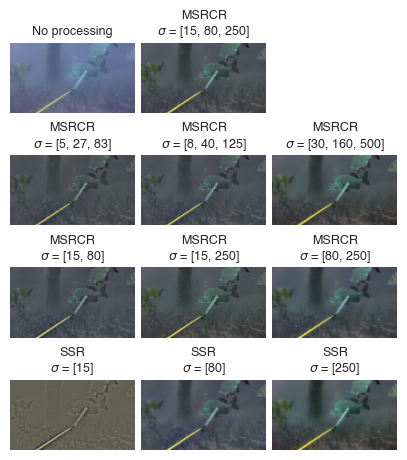

In [25]:
dataset = 'DeepFish'
fn = '9866_acanthopagrus_and_caranx_f000054.jpg'

MSR = [
    'resized',
    'resized_MSRCR_15_80_250_new',
    None,
    
    'resized_MSRCR_5_27_83_new',
    'resized_MSRCR_8_40_125_new',
    'resized_MSRCR_30_160_500_new',

    'resized_MSRCR_15_80_new',
    'resized_MSRCR_15_250_new',
    'resized_MSRCR_80_250_new',

    'resized_SSR_15_new',
    'resized_SSR_80_new',
    'resized_SSR_250_new'
]

fig, axs = plt.subplots(4, 3, figsize=(5, 5.5))
plt.subplots_adjust(wspace=0.05, hspace=0.3)

for i, ax in enumerate(axs.flatten()):
    ax.axis('off')
    if MSR[i] is not None:
        filename = os.path.join(data_dir, 'resources', dataset, MSR[i], fn)
        image = utils.read_image(filename)
        assert image is not None
        # h, w = image.shape[:2]
        # assert w > h
        # image = image[:, int((w - h) * offset_left):w - int((w - h) * offset_right), :]

        ax.imshow(utils.flip_color_channels(image))
        sigmas = MSR[i].split('_')[2:-1]
        ax.set_title(f"{'MSRCR' if len(sigmas) > 1 else 'SSR'}\n$\sigma$ = [{', '.join(sigmas)}]" if MSR[i] != 'resized' else 'No processing')
utils.savefig(os.path.join(results_dir, 'figures', 'MSR_comparison.svg'), dpi=600, bbox_inches='tight')
plt.show()

1
1
1


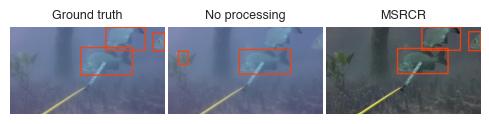

1
1
1


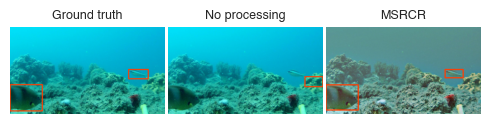

6
3
1


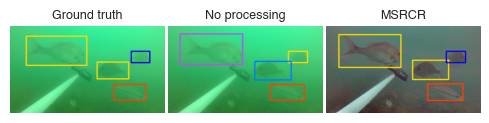

6
6
6


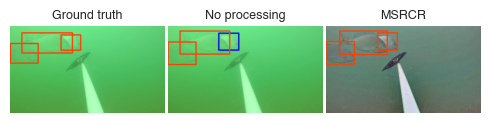

7
6
7


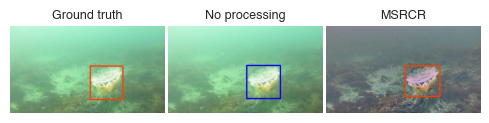

1
1
1


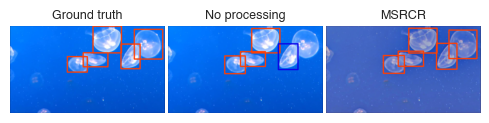

3
1
2


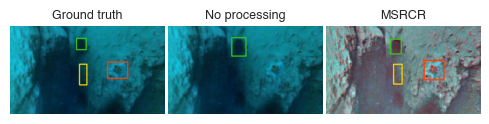

In [46]:
THICKNESS = 9
SPLIT = 'test'
CONF_THR = 0.5

GLOW_PAL1 = (np.asarray(sns.color_palette('bright'))[[9, 7, 0, 1, 6, 3]] * 255).tolist()
GLOW_PAL2 = (np.asarray(sns.color_palette('bright'))[[9, 7, 3, 3, 6, 0]] * 255).tolist()
JELLY_PAL1 = (np.asarray(sns.color_palette('bright'))[[3] * 6 + [0] + [3] * 8] * 255).tolist()
JELLY_PAL2 = (np.asarray(sns.color_palette('bright'))[[0] + [3] * 14] * 255).tolist()
SUODAC_PAL = (np.asarray(sns.color_palette('bright'))[[2, 0, 9, 6, 6, 6]] * 255).tolist()

for pckl_fn, palette in [
    ('yolo8.DeepFish.seed2.ground_truth.9866_acanthopagrus_and_caranx_f000054', 'bright'),
    ('yolo8.DeepFish.seed9.ground_truth.7482_F2_f000120', 'bright'),
    ('yolo8.GLOW_low_visibility_estuaries.seed9.ground_truth.SH4b-27-08-2018_SH4b BRUV 27 August 2018 (1)-17-of-27.MP4_5fps_000012', GLOW_PAL1),
    ('yolo8.GLOW_low_visibility_estuaries.seed17.ground_truth.GI3-20-03-2019_Rhabdosargus sarba 3.34 secchi GI3 20 March 2019 (2).mp4_5fps_000072', GLOW_PAL2),
    ('yolo8.Jellytoring.seed2.ground_truth.lamarckii3_13', JELLY_PAL1),
    ('yolo8.Jellytoring.seed7.ground_truth.aurita2_11', JELLY_PAL2),
    ('yolo8.S-UODAC.seed1.ground_truth.type7_003605', SUODAC_PAL),    
]:
    model, dataset, seed = pckl_fn.split('.')[:3]
    seed = int(seed.replace('seed', ''))
    file_name = '.'.join(pckl_fn.split('.')[4:])
    fig, axs = plt.subplots(1, 3, figsize=(15.4 * C.CM, 3 * C.CM))
    plt.subplots_adjust(wspace=0.025, hspace=0.05)
    
    eval_type = 'Groups' if dataset != 'S-UODAC' else 'NoValRepro'
    model_select = 'best' if dataset != 'S-UODAC' else 'last'
        
    for ax, (pps, thickness) in zip(axs, [
        ('ground_truth', round(THICKNESS * ((1920 / 1280) if dataset == 'DeepFish' else 1))),
        (None, round(THICKNESS * ((1920 / 1280) if dataset == 'DeepFish' else 1))),
        ('resized_MSRCR_15_80_250_new', round(THICKNESS * ((1333 / 1280) if dataset == 'DeepFish' else 1))),

    ]):
        fn = os.path.join(results_dir, 'figures', 'examples', f"{model}.{dataset}.seed{seed}.{pps}.{file_name}")
        plot_img_dict = utils.pickle_load(f'{fn}.jpg.pckl')
        
        print(plot_img_dict['annotations'][0]['category_id'])
        image = utils.plot_bboxes(palette=palette, draw_labels=False, thickness=thickness, **plot_img_dict)
        ax.imshow(utils.flip_color_channels(image))
        ax.axis('off')
        ax.set_title('Ground truth' if pps == 'ground_truth' else C.RENAME_PPS.get(pps, pps))
    utils.savefig(f'{fn}.svg', dpi=600, bbox_inches='tight')
    plt.show()
    # break